# Matrix Factorization using SVD

Build recommendation system using Singular Value Decomposition (SVD).

In [17]:
import sys
sys.path.append('../src')
sys.path.append('../evaluation')

import pandas as pd
import numpy as np
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split
from metrics import rmse, mae, precision_at_k, recall_at_k, ndcg_at_k
import matplotlib.pyplot as plt

## 1. Load Data

In [18]:
# Load data
ratings = pd.read_csv('../data/processed/ratings.csv')
user_item_matrix = pd.read_csv('../data/processed/user_item_matrix.csv', index_col=0)

print(f"Data shape: {user_item_matrix.shape}")

Data shape: (943, 1682)


## 2. Split Train-Test

In [19]:
# Split data
train_ratings, test_ratings = train_test_split(ratings, test_size=0.2, random_state=42)

# Create matrices
train_matrix = train_ratings.pivot_table(index='user_id', columns='item_id', values='rating').fillna(0)
test_matrix = test_ratings.pivot_table(index='user_id', columns='item_id', values='rating').fillna(0)

print(f"Train shape: {train_matrix.shape}")
print(f"Test shape: {test_matrix.shape}")

Train shape: (943, 1653)
Test shape: (940, 1411)


## 3. SVD Matrix Factorization

In [20]:
class SVDRecommender:
    """Matrix factorization using SVD"""

    def __init__(self, n_factors=50):
        self.n_factors = n_factors
        self.svd = TruncatedSVD(n_components=n_factors, random_state=42)
        self.user_factors = None
        self.item_factors = None
        self.user_indices = None
        self.item_indices = None

    def fit(self, matrix):
        """Fit SVD model"""
        self.user_indices = matrix.index.tolist()
        self.item_indices = matrix.columns.tolist()

        # Apply SVD
        self.user_factors = self.svd.fit_transform(matrix)
        self.item_factors = self.svd.components_.T

        return self

    def predict(self, user_id, item_id):
        """Predict rating for user-item pair"""
        if user_id not in self.user_indices or item_id not in self.item_indices:
            return 3.0  # Default rating

        user_idx = self.user_indices.index(user_id)
        item_idx = self.item_indices.index(item_id)

        pred = np.dot(self.user_factors[user_idx], self.item_factors[item_idx])

        # Clip to valid rating range
        return np.clip(pred, 0.5, 5.0)

    def recommend_for_user(self, user_id, n_items=10):
        """Recommend top-N items for user"""
        if user_id not in self.user_indices:
            return []

        user_idx = self.user_indices.index(user_id)

        # Get predicted ratings for all items
        predictions = np.dot(self.user_factors[user_idx], self.item_factors.T)

        # Get top-N items
        top_indices = np.argsort(predictions)[::-1][:n_items]

        return [self.item_indices[idx] for idx in top_indices]

# Train SVD model
svd_model = SVDRecommender(n_factors=50)
svd_model.fit(train_matrix)

print("SVD model trained!")
print(f"User factors shape: {svd_model.user_factors.shape}")
print(f"Item factors shape: {svd_model.item_factors.shape}")

SVD model trained!
User factors shape: (943, 50)
Item factors shape: (1653, 50)


## 4. Evaluate SVD Model

In [21]:
# Evaluate on full test set
predictions, actual = [], []

for _, row in test_ratings.iterrows():
    uid, iid, r = int(row['user_id']), int(row['item_id']), row['rating']
    if uid in svd_model.user_indices and iid in svd_model.item_indices:
        predictions.append(svd_model.predict(uid, iid))
        actual.append(r)

if predictions:
    rmse_score = rmse(actual, predictions)
    mae_score = mae(actual, predictions)
    print(f"SVD Model Results:")
    print(f"  RMSE: {rmse_score:.4f}")
    print(f"  MAE:  {mae_score:.4f}")
    print(f"  Test samples: {len(predictions):,}")

SVD Model Results:
  RMSE: 2.7220
  MAE:  2.4731
  Test samples: 19,969


## 5. Explore Latent Factors

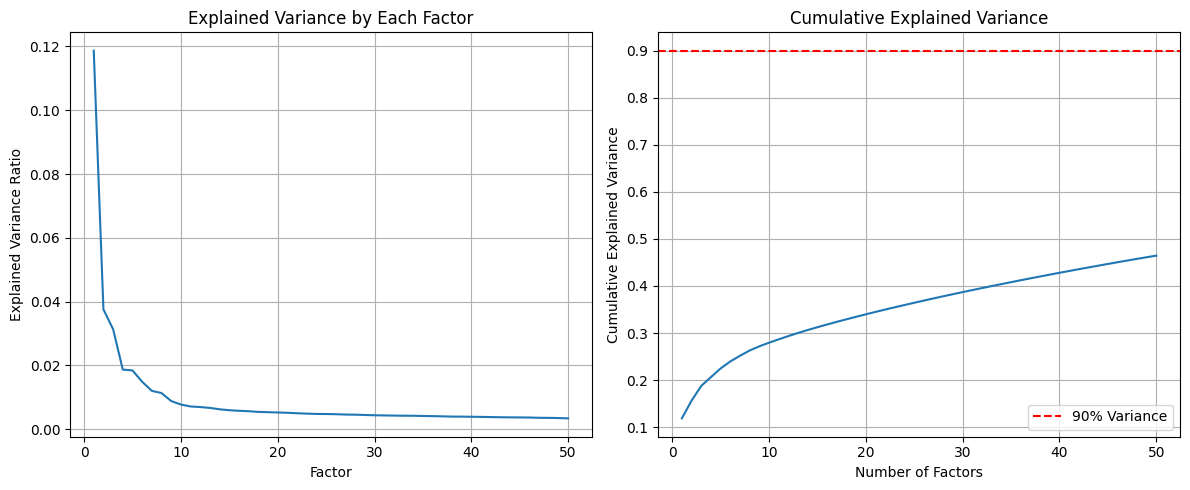

Variance explained by 50 factors: 0.4645
Factors needed for 90% variance: 1


In [22]:
# Visualize variance explained by factors
explained_variance = svd_model.svd.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(explained_variance) + 1), explained_variance)
plt.xlabel('Factor')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by Each Factor')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance)
plt.axhline(y=0.9, color='r', linestyle='--', label='90% Variance')
plt.xlabel('Number of Factors')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Variance explained by 50 factors: {cumulative_variance[-1]:.4f}")
print(f"Factors needed for 90% variance: {np.argmax(cumulative_variance >= 0.9) + 1}")

## 6. Get Recommendations

In [23]:
# Get movie titles for human-readable output
from data_loader import MovieLensDataLoader
_loader = MovieLensDataLoader()
_loader.load_data()
movie_titles = dict(zip(_loader.movies['item_id'], _loader.movies['title']))

# Get recommendations for sample users
for user_id in [1, 5, 10]:
    recs = svd_model.recommend_for_user(user_id, n_items=10)
    print(f"\n=== Top 10 SVD recommendations for User {user_id} ===")
    for rank, item_id in enumerate(recs, start=1):
        print(f"  {rank:2}. [{item_id:4d}] {movie_titles.get(item_id, 'Unknown')}")


=== Top 10 SVD recommendations for User 1 ===
   1. [ 176] Aliens (1986)
   2. [ 268] Chasing Amy (1997)
   3. [  50] Star Wars (1977)
   4. [ 127] Godfather, The (1972)
   5. [ 202] Groundhog Day (1993)
   6. [ 216] When Harry Met Sally... (1989)
   7. [  12] Usual Suspects, The (1995)
   8. [  89] Blade Runner (1982)
   9. [ 168] Monty Python and the Holy Grail (1974)
  10. [ 228] Star Trek: The Wrath of Khan (1982)

=== Top 10 SVD recommendations for User 5 ===
   1. [ 181] Return of the Jedi (1983)
   2. [ 168] Monty Python and the Holy Grail (1974)
   3. [  50] Star Wars (1977)
   4. [ 172] Empire Strikes Back, The (1980)
   5. [ 100] Fargo (1996)
   6. [ 222] Star Trek: First Contact (1996)
   7. [ 228] Star Trek: The Wrath of Khan (1982)
   8. [ 257] Men in Black (1997)
   9. [   1] Toy Story (1995)
  10. [ 209] This Is Spinal Tap (1984)

=== Top 10 SVD recommendations for User 10 ===
   1. [ 286] English Patient, The (1996)
   2. [ 100] Fargo (1996)
   3. [ 357] One Flew Over 

## 7. Hyperparameter Tuning

  Factors= 10 => RMSE=2.4805
  Factors= 20 => RMSE=2.4832
  Factors= 30 => RMSE=2.5451
  Factors= 40 => RMSE=2.6029
  Factors= 50 => RMSE=2.6769
  Factors= 60 => RMSE=2.7273
  Factors= 70 => RMSE=2.7687


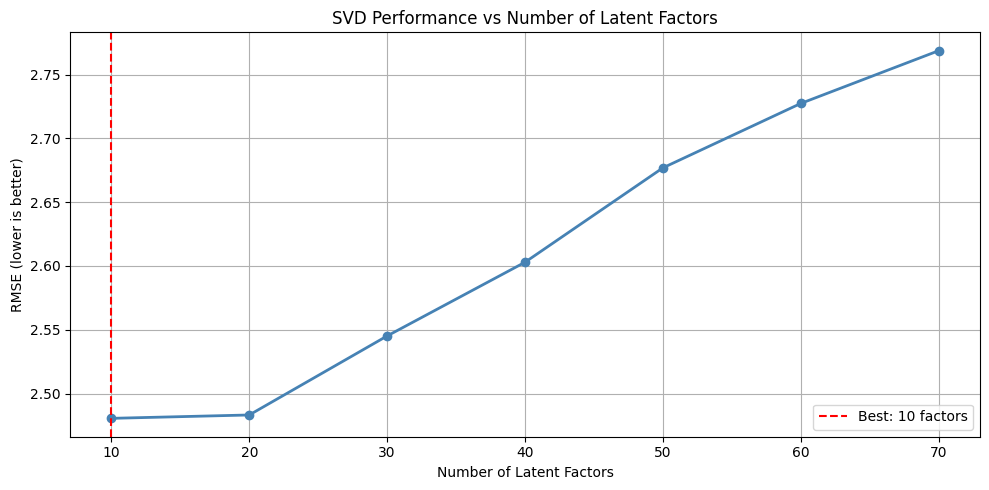


Best: 10 factors with RMSE = 2.4805


In [24]:
# Test different numbers of latent factors
factors_list = [10, 20, 30, 40, 50, 60, 70]
rmse_scores = []

for n_factors in factors_list:
    model = SVDRecommender(n_factors=n_factors)
    model.fit(train_matrix)

    predictions, actual = [], []
    for _, row in test_ratings.head(500).iterrows():
        uid, iid, r = int(row['user_id']), int(row['item_id']), row['rating']
        if uid in model.user_indices and iid in model.item_indices:
            predictions.append(model.predict(uid, iid))
            actual.append(r)

    score = rmse(actual, predictions)
    rmse_scores.append(score)
    print(f"  Factors={n_factors:3d} => RMSE={score:.4f}")

# Plot
plt.figure(figsize=(10, 5))
plt.plot(factors_list, rmse_scores, marker='o', linewidth=2, color='steelblue')
best_f = factors_list[int(np.argmin(rmse_scores))]
plt.axvline(x=best_f, color='red', linestyle='--', label=f'Best: {best_f} factors')
plt.xlabel('Number of Latent Factors')
plt.ylabel('RMSE (lower is better)')
plt.title('SVD Performance vs Number of Latent Factors')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
print(f"\nBest: {best_f} factors with RMSE = {min(rmse_scores):.4f}")